### Modelo de red neuronal para detectar numeros hechos a mano alzada

Cuantas neuronas necesitamos a la salida de mi red neuronal?:
Podría ser 1 sola neurona utilizando regresión, o 10 neuronas usando clasificación para los números de 0 a 9.

In [6]:
# Determine cual python está utilizando
!python --version

Python 3.12.12


In [2]:
import tensorflow as tf

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.10.0


In [3]:
# Mostrar la información de la GPU que estamos usando
!nvidia-smi

Fri Feb 20 20:47:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [5]:
# Normalize the images by dividing by 255
x_train = x_train / 255.0
x_test = x_test / 255.0

print(f"x_train normalized - min: {x_train.min()}, max: {x_train.max()}")
print(f"x_test normalized - min: {x_test.min()}, max: {x_test.max()}")

x_train normalized - min: 0.0, max: 1.0
x_test normalized - min: 0.0, max: 1.0


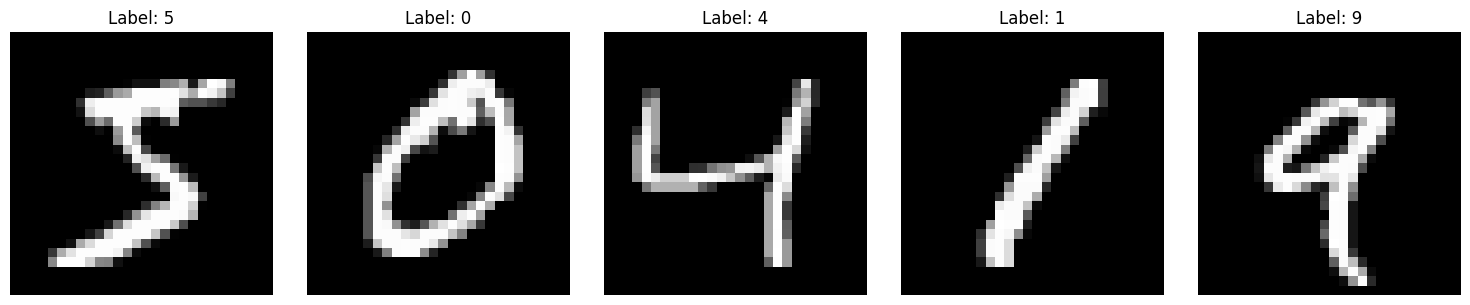

In [7]:
import matplotlib.pyplot as plt

# Display the first 5 images from x_train with their corresponding labels
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [8]:
# Show the shape of a single image from x_train
print(f"Shape of a single image: {x_train[0].shape}")
print(f"This represents a {x_train[0].shape[0]}x{x_train[0].shape[1]} pixel image")

Shape of a single image: (28, 28)
This represents a 28x28 pixel image


In [9]:
# Create a sequential dense neural network
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,650 (205.66 KB)

 Trainable params: 52,650 (205.66 KB)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# Flatten the images from 28x28 to 784 features
x_train_flattened = x_train.reshape(-1, 784)
x_test_flattened = x_test.reshape(-1, 784)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train_flattened, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8459 - loss: 0.5177 - val_accuracy: 0.9598 - val_loss: 0.1387
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9542 - loss: 0.1523 - val_accuracy: 0.9675 - val_loss: 0.1071
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9690 - loss: 0.1002 - val_accuracy: 0.9702 - val_loss: 0.1006
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9744 - loss: 0.0791 - val_accuracy: 0.9702 - val_loss: 0.1107
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9787 - loss: 0.0669 - val_accuracy: 0.9730 - val_loss: 0.0939
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9837 - loss: 0.0506 - val_accuracy: 0.9712 - val_loss: 0.1025
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9859 - loss: 0.0453 - val_accuracy: 0.9757 - val_loss: 0.0873
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9868 - loss: 0.0405 - 

In [12]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(x_test_flattened, y_test)

print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9709 - loss: 0.1199
Test Loss: 0.1050167828798294
Test Accuracy: 0.9735000133514404


In [ ]:
model.save('mnist_model.h5')
print("Model saved as 'mnist_model.h5'")

/bin/bash: -c: line 1: syntax error near unexpected token `'mnist_model.h5''
/bin/bash: -c: line 1: `model.save('mnist_model.h5')'
Model saved as 'mnist_model.h5'
